#FASE 1: Exploración Inicial del Dataset
## Medicamentos Vitales No Disponibles — INVIMA (2018–2026)

**Proyecto:** Entre la necesidad y la disponibilidad  
**Autores:** Julian David Medina Ceballos | Laura Catalina Mariaca Varona  
**Institución:** Unicomfacauca — Diplomado en Ingeniería y Ciencia de Datos Aplicada  

---

### ¿Qué hace este notebook?
Este es el **primer paso** de cualquier proyecto de datos: conocer el dataset tal como está, antes de limpiar o analizar los datos en general.  
Al terminar sabremos exactamente **qué tenemos, qué falta y qué hay que corregir**.

### Secciones:
1. Instalación de librerías y carga del archivo  
2. Dimensiones y estructura del dataset  
3. Tipos de datos por columna  
4. Análisis de valores nulos y faltantes  
5. Detección de duplicados  
6. Exploración de variables categóricas  
7. Exploración de la unica variable numérica  
8. Vista de muestra del dataset  
9. Resumen ejecutivo del diagnóstico

#CARGA DEL DATASET INICIAL

---
## SECCIÓN 1 — Instalación de librerías y carga del dataset

In [31]:
# Instalar librerías necesarias
%pip install pandas openpyxl matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
# ─── Importar librerías ──────────────────────────────────────────────────────
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual inicial para todas las graficas presentadas durante el notebook exploratorio
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(f'   sys      : {sys.version}')
print(f'   pandas   : {pd.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   matplotlib: {plt.matplotlib.__version__}')
print(f'   seaborn  : {sns.__version__}')

   sys      : 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
   pandas   : 2.3.3
   numpy    : 2.3.5
   matplotlib: 3.10.0
   seaborn  : 0.13.2


In [67]:
# ─── Cargar el dataset ───────────────────────────────────────────────────────

# Ruta del archivo Dataset
RUTA_ARCHIVO = '../datasets/MEDICAMENTOS_VITALES_NO_DISPONIBLES_20260425.xlsx'

df = pd.read_excel(
    RUTA_ARCHIVO,
    sheet_name='Data',          # Nombre de la hoja en el archivo
    parse_dates=['FECHA_DE_AUTORIZACIÓN']  # Convertir la fecha automáticamente
)

# Limpiar espacios en nombres de columnas (por si acaso)
df.columns = df.columns.str.strip()

print(f' Dataset cargado exitosamente')


 Dataset cargado exitosamente


---
## SECCIÓN 2 — Dimensiones y estructura del dataset

In [34]:
# ─── Dimensiones ─────────────────────────────────────────────────────────────

print('  DIMENSIONES DEL DATASET')

print(f'  Total de registros (filas) : {df.shape[0]:>8,}')
print(f'  Total de variables (cols)  : {df.shape[1]:>8}')
print(f'  Total de celdas            : {df.shape[0]*df.shape[1]:>8,}')

  DIMENSIONES DEL DATASET
  Total de registros (filas) :   10,017
  Total de variables (cols)  :       16
  Total de celdas            :  160,272


In [35]:
# ─── Lista de columnas con descripción ──────────────────────────────────────
descripcion = {
    'FECHA_DE_AUTORIZACIÓN'            : 'Fecha en que el INVIMA expidió la autorización',
    'TIPO_DE_SOLICITUD'                : 'Paciente específico / Más de un paciente / Urgencia clínica',
    'SOLICITANTE/IMPORTADOR'           : 'Empresa importadora autorizada por el INVIMA',
    'IUM'                              : 'Identificador Único del Medicamento (código INVIMA)',
    'PRINCIPIO_ACTIVO1'               : 'Nombre del principio activo principal (DCI)',
    'CONCENTRACIÓN_DELMEDICAMENTO1'    : 'Concentración del principio activo 1',
    'UNIDAD_MEDIDA1'                   : 'Unidad de medida de concentración 1 (mg, UI, mcg...)',
    'PRINCIPIO_ACTIVO2'               : 'Principio activo secundario (si aplica)',
    'CONCENTRACIÓN_DEL_MEDICAMENTO2'   : 'Concentración del principio activo 2',
    'UNIDAD_MEDIDA2'                   : 'Unidad de medida de concentración 2',
    'FORMA_FARMACÉUTICA'              : 'Forma física del medicamento (tableta, solución...)',
    'NOMBRE_COMERCIAL_'               : 'Nombre de marca del medicamento',
    'CANTIDAD_SOLICITADA'              : 'Número de unidades autorizadas para importar',
    'PRESENTACIÓN_COMERCIAL'          : 'Descripción del empaque',
    'DIAGNOSTICO_CIE-1NO REPORTA'     : 'Nombre del diagnóstico según CIE-10',
    'CÓDIGO_DIAGNOSTICO_CIE-10'       : 'Código alfanumérico del diagnóstico (ej: E849)'
}

print(f'{"COLUMNA":<40} {"DESCRIPCIÓN"}')
print('-' * 90)
for col, desc in descripcion.items():
    print(f'{col:<40} {desc}')

COLUMNA                                  DESCRIPCIÓN
------------------------------------------------------------------------------------------
FECHA_DE_AUTORIZACIÓN                    Fecha en que el INVIMA expidió la autorización
TIPO_DE_SOLICITUD                        Paciente específico / Más de un paciente / Urgencia clínica
SOLICITANTE/IMPORTADOR                   Empresa importadora autorizada por el INVIMA
IUM                                      Identificador Único del Medicamento (código INVIMA)
PRINCIPIO_ACTIVO1                        Nombre del principio activo principal (DCI)
CONCENTRACIÓN_DELMEDICAMENTO1            Concentración del principio activo 1
UNIDAD_MEDIDA1                           Unidad de medida de concentración 1 (mg, UI, mcg...)
PRINCIPIO_ACTIVO2                        Principio activo secundario (si aplica)
CONCENTRACIÓN_DEL_MEDICAMENTO2           Concentración del principio activo 2
UNIDAD_MEDIDA2                           Unidad de medida de concentraci

---
## SECCIÓN 3 — Tipos de datos por columna

In [61]:
# ─── Tipos de datos detectados automáticamente por pandas ────────────────────
resumen_tipos = pd.DataFrame({
    'Tipo pandas'   : df.dtypes})
print(resumen_tipos.to_string())



                                   Tipo pandas
FECHA_DE_AUTORIZACIÓN           datetime64[ns]
TIPO_DE_SOLICITUD                       object
SOLICITANTE/IMPORTADOR                  object
IUM                                     object
PRINCIPIO_ACTIVO1                       object
CONCENTRACIÓN_DELMEDICAMENTO1           object
UNIDAD_MEDIDA1                          object
PRINCIPIO_ACTIVO2                       object
CONCENTRACIÓN_DEL_MEDICAMENTO2          object
UNIDAD_MEDIDA2                          object
FORMA_FARMACÉUTICA                      object
NOMBRE_COMERCIAL_                       object
CANTIDAD_SOLICITADA                    float64
PRESENTACIÓN_COMERCIAL                  object
DIAGNOSTICO_CIE-1NO REPORTA             object
CÓDIGO_DIAGNOSTICO_CIE-10               object


---
##  SECCIÓN 4 — Análisis de valores nulos y faltantes

En este dataset, los "nulos" tienen dos formas:  
- Celdas vacías (`NaN` real)
- Texto como `'NO REPORTADO'`, `'NO APLICA'` (nulos disfrazados de texto)

Ambos los contamos juntos para tener el panorama real.

In [68]:
# ─── Función para detectar nulos reales + nulos disfrazados ─────────────────
VALORES_NULOS = ['NO APLICA', 'NO REPORTADO', 'NO REPORTA', 'NO REPORTA ', '', ' ']

def contar_faltantes(col):
    #Cuenta NaN + valores textuales que representan ausencia de dato.
    es_nan = col.isna()
    es_texto_nulo = col.astype(str).str.strip().str.upper().isin([v.upper() for v in VALORES_NULOS])
    return (es_nan | es_texto_nulo).sum()

# tabla de diagnóstico de la informacion de nulos presentados
diagnostico = pd.DataFrame(index=df.columns)
diagnostico['Nulos NaN reales']      = df.isna().sum()
diagnostico['Nulos disfrazados']     = [contar_faltantes(df[c]) - df[c].isna().sum() for c in df.columns]
diagnostico['Total faltantes']       = [contar_faltantes(df[c]) for c in df.columns]
diagnostico['% Faltante']            = (diagnostico['Total faltantes'] / len(df) * 100).round(1)
diagnostico['Registros válidos']     = len(df) - diagnostico['Total faltantes']
diagnostico = diagnostico.sort_values('Total faltantes', ascending=False)

print(diagnostico.to_string())

                                Nulos NaN reales  Nulos disfrazados  Total faltantes  % Faltante  Registros válidos
UNIDAD_MEDIDA2                                21               9168             9189        91.7                828
CONCENTRACIÓN_DEL_MEDICAMENTO2                19               9167             9186        91.7                831
PRINCIPIO_ACTIVO2                             21               9155             9176        91.6                841
CÓDIGO_DIAGNOSTICO_CIE-10                      0               1777             1777        17.7               8240
DIAGNOSTICO_CIE-1NO REPORTA                    0               1338             1338        13.4               8679
NOMBRE_COMERCIAL_                              0                957              957         9.6               9060
CANTIDAD_SOLICITADA                           59                  0               59         0.6               9958
FORMA_FARMACÉUTICA                            37                  0     

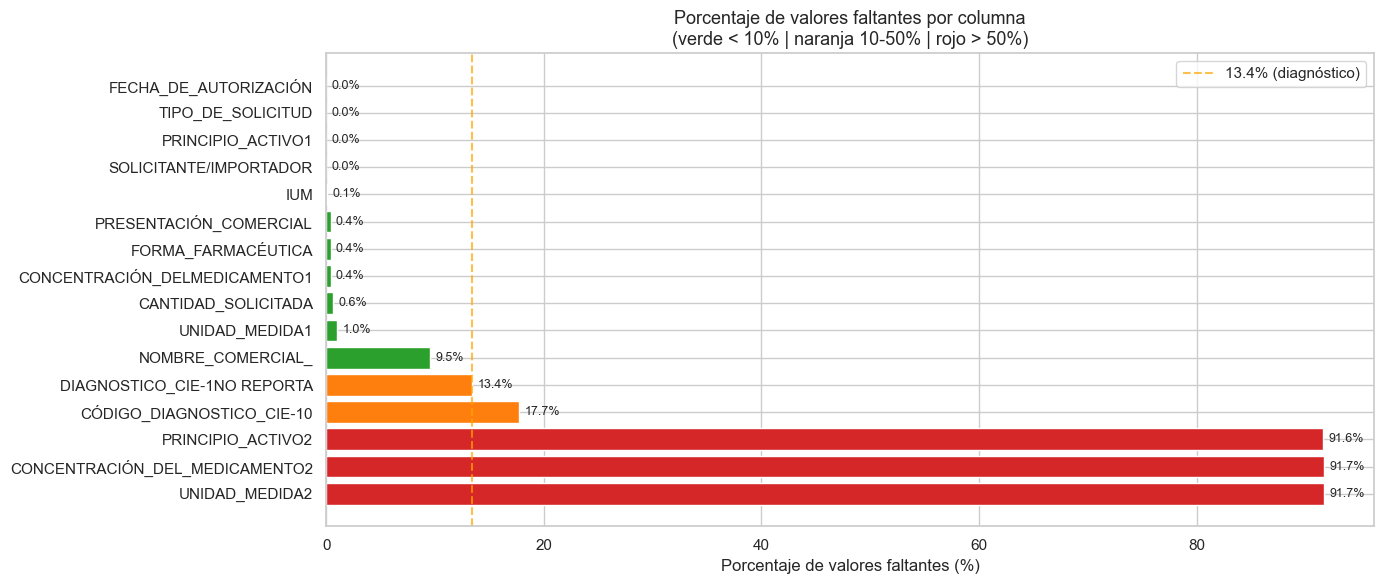

 Gráfico guardado como grafico_nulos.png


In [38]:
# ─── Gráfico de barras: porcentaje de faltantes por columna ─────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colores = ['#d62728' if p > 50 else '#ff7f0e' if p > 10 else '#2ca02c'
           for p in diagnostico['% Faltante']]

bars = ax.barh(diagnostico.index, diagnostico['% Faltante'], color=colores)

# Etiquetas de valor
for bar, val in zip(bars, diagnostico['% Faltante']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

# Línea de referencia al 13.4% (diagnóstico CIE-10)
ax.axvline(x=13.4, color='orange', linestyle='--', alpha=0.7, label='13.4% (diagnóstico)')

ax.set_xlabel('Porcentaje de valores faltantes (%)')
ax.set_title('Porcentaje de valores faltantes por columna\n(verde < 10% | naranja 10-50% | rojo > 50%)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../graficos/graficos_explo_inicial/grafico_nulos.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico guardado como grafico_nulos.png')

---
##  SECCIÓN 5 — Detección de duplicados

In [69]:
from IPython.display import display

# ─── Duplicados exactos (todas las columnas iguales) ────────────────────────
n_dup = df.duplicated().sum()
print(f'Filas exactamente duplicadas : {n_dup}')

# Mostrar TODOS los duplicados completos
duplicados_exactos = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

print("\n REGISTROS DUPLICADOS COMPLETOS:")
display(duplicados_exactos)

Filas exactamente duplicadas : 604

 REGISTROS DUPLICADOS COMPLETOS:


,FECHA_DE_AUTORIZACIÓN,TIPO_DE_SOLICITUD,SOLICITANTE/IMPORTADOR,IUM,PRINCIPIO_ACTIVO1,CONCENTRACIÓN_DELMEDICAMENTO1,UNIDAD_MEDIDA1,PRINCIPIO_ACTIVO2,CONCENTRACIÓN_DEL_MEDICAMENTO2,UNIDAD_MEDIDA2,FORMA_FARMACÉUTICA,NOMBRE_COMERCIAL_,CANTIDAD_SOLICITADA,PRESENTACIÓN_COMERCIAL,DIAGNOSTICO_CIE-1NO REPORTA,CÓDIGO_DIAGNOSTICO_CIE-10
10011,2018-01-11 05:00:00,MÁS DE UN PACIENTE,MEDICAL KIT LTDA.,1S1011611000100,FABOTERAPICO POLIVALENTE ANTIALACRAN,1.8,mg,NO APLICA,NO APLICA,NO APLICA,POLVO LIOFILIZADO PARA RECONSTITUIR A SOLUCIÓN...,ALACRAMYN,1500.0,"CAJA X 1 VIAL X 1,8mg",NO REPORTADO,NO REPORTADO
10012,2018-01-11 05:00:00,MÁS DE UN PACIENTE,MEDICAL KIT LTDA.,1S1011611000100,FABOTERAPICO POLIVALENTE ANTIALACRAN,1.8,mg,NO APLICA,NO APLICA,NO APLICA,POLVO LIOFILIZADO PARA RECONSTITUIR A SOLUCIÓN...,ALACRAMYN,1500.0,"CAJA X 1 VIAL X 1,8mg",NO REPORTADO,NO REPORTADO
9821,2018-03-21 05:00:00,PACIENTE ESPECIFICO,GLOBAL SERVICE PHARMACEUTICAL S.A.S.,1E1004581000101,EPINEFRINA,"0,3/0,3",mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCIÓN INYECTABLE,EPIPEN,1.0,"CAJA X UN AUTOINYECTOR X 0,3 ML","CHOQUE ANAFILACTICO, NO ESPECIFICADO",T782
9823,2018-03-21 05:00:00,PACIENTE ESPECIFICO,GLOBAL SERVICE PHARMACEUTICAL S.A.S.,1E1004581000101,EPINEFRINA,"0,3/0,3",mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCIÓN INYECTABLE,EPIPEN,1.0,"CAJA X UN AUTOINYECTOR X 0,3 ML","CHOQUE ANAFILACTICO, NO ESPECIFICADO",T782
9781,2018-04-06 05:00:00,URGENCIA CLÍNICA,SANOFI AVENTIS DE COLOMBIA S.A.,1D1023251000100,DUPILUMAB,150,mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCIÓN INYECTABLE,DUPIXENT,7.0,CAJA X 2 JERINGAS X 2mL,"DERMATITIS ATOPICA, NO ESPECIFICADA",L209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2026-03-03 05:00:00,MÁS DE UN PACIENTE,SICMAFARMA S.A.S.,1N1025871007101,NOREPINEFRINA,1,mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCIÓN INYECTABLE,NO REPORTADO,3330.0,CAJAS X 10 AMPOLLAS,ANGINA INESTABLE,I200
26,2026-03-12 05:00:00,PACIENTE ESPECIFICO,SALUTIS SAS - AUDIFARMA SA,1A1000141000100,ATALUREN,250,mg,NO APLICA,NO APLICA,NO APLICA,POLVO GRANULADO PARA RECONSTITUIR A SUSPENSIÓN...,TRANSLARNA,24.0,CAJAS X 30 SOBRES,DISTROFIA MUSCULAR,G710
29,2026-03-12 05:00:00,PACIENTE ESPECIFICO,SALUTIS SAS - AUDIFARMA SA,1A1000141000100,ATALUREN,250,mg,NO APLICA,NO APLICA,NO APLICA,POLVO GRANULADO PARA RECONSTITUIR A SUSPENSIÓN...,TRANSLARNA,24.0,CAJAS X 30 SOBRES,DISTROFIA MUSCULAR,G710
27,2026-03-12 05:00:00,PACIENTE ESPECIFICO,SALUTIS SAS - AUDIFARMA SA,1A1001711000100,ATALUREN,125,mg,NO APLICA,NO APLICA,NO APLICA,POLVO GRANULADO PARA RECONSTITUIR A SUSPENSIÓN...,TRANSLARNA,6.0,CAJAS X 30 SOBRES,DISTROFIA MUSCULAR,G710


---
## SECCIÓN 6 — Exploración de variables categóricas clave

Analizamos las distribuciones de las variables de texto más importantes del proyecto.

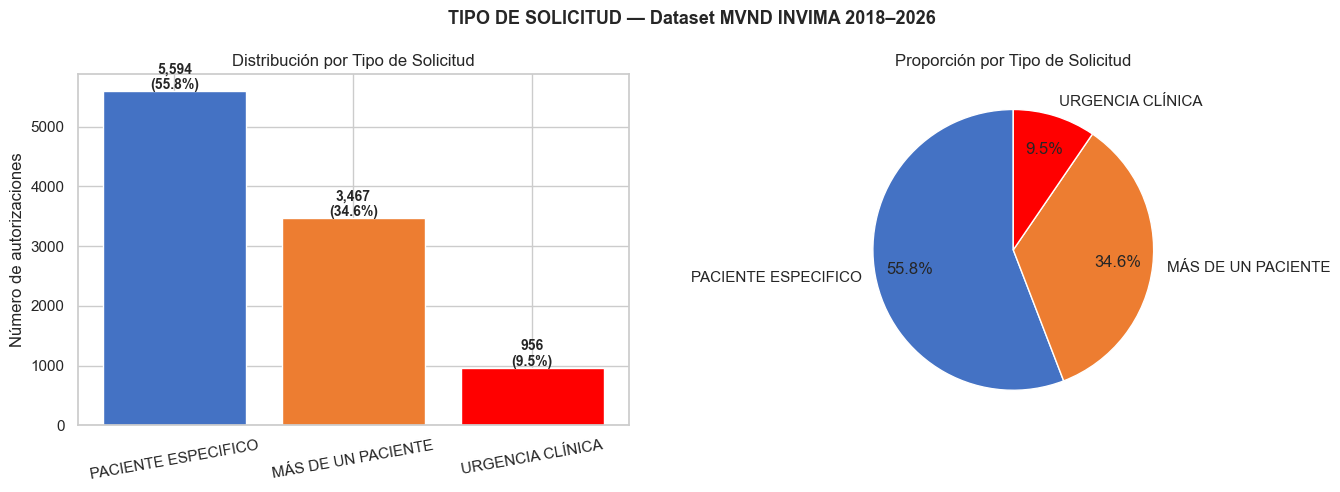


Conteo:
                     Cantidad  Porcentaje (%)
TIPO_DE_SOLICITUD                            
PACIENTE ESPECIFICO      5594            55.8
MÁS DE UN PACIENTE       3467            34.6
URGENCIA CLÍNICA          956             9.5


In [47]:
# ─── 6.1 TIPO_DE_SOLICITUD ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tipo_counts = df['TIPO_DE_SOLICITUD'].value_counts()
tipo_pct    = (tipo_counts / len(df) * 100).round(1)

# Barras
colores_tipo = ['#4472C4', '#ED7D31', '#FF0000']
bars = ax1.bar(tipo_counts.index, tipo_counts.values, color=colores_tipo)
for bar, val, pct in zip(bars, tipo_counts.values, tipo_pct.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Distribución por Tipo de Solicitud', fontsize=12)
ax1.set_ylabel('Número de autorizaciones')
ax1.tick_params(axis='x', labelrotation=10)

# Torta
ax2.pie(tipo_counts.values, labels=tipo_counts.index,
        autopct='%1.1f%%', colors=colores_tipo,
        startangle=90, pctdistance=0.75)
ax2.set_title('Proporción por Tipo de Solicitud', fontsize=12)

plt.suptitle('TIPO DE SOLICITUD — Dataset MVND INVIMA 2018–2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/graficos_explo_inicial/grafico_tipo_solicitud.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConteo:')
print(pd.DataFrame({'Cantidad': tipo_counts, 'Porcentaje (%)': tipo_pct}))

---
## SECCIÓN 7 — Exploración outliers de la unica variable numérica: CANTIDAD_SOLICITADA

In [57]:
# ─── Estadísticas descriptivas de CANTIDAD_SOLICITADA ────────────────────────
cantidad = pd.to_numeric(df['CANTIDAD_SOLICITADA'], errors='coerce').dropna()

print('ESTADÍSTICAS DE CANTIDAD_SOLICITADA:')
print(f'  Registros válidos : {len(cantidad):,}')
print(f'  Media             : {cantidad.mean():,.1f}')
print(f'  Mediana           : {cantidad.median():,.1f}')
print(f'  Mínimo            : {cantidad.min():,}')
print(f'  Máximo            : {cantidad.max():,}')
print(f'  Desv. estándar    : {cantidad.std():,.1f}')
print(f'  Q1 (25%)          : {cantidad.quantile(0.25):,}')
print(f'  Q3 (75%)          : {cantidad.quantile(0.75):,}')
print(f'  IQR               : {cantidad.quantile(0.75) - cantidad.quantile(0.25):,}')
print()

# La diferencia media-mediana indica sesgo
if cantidad.mean() > cantidad.median() * 2:
    print('La media es mucho mayor que la mediana → distribución muy sesgada a la derecha.')
    print('Hay registros con cantidades muy altas (outliers). Revisar en ETL.')

ESTADÍSTICAS DE CANTIDAD_SOLICITADA:
  Registros válidos : 9,958
  Media             : 2,960.6
  Mediana           : 20.0
  Mínimo            : 1.0
  Máximo            : 304,475.0
  Desv. estándar    : 14,050.0
  Q1 (25%)          : 6.0
  Q3 (75%)          : 315.0
  IQR               : 309.0

La media es mucho mayor que la mediana → distribución muy sesgada a la derecha.
Hay registros con cantidades muy altas (outliers). Revisar en ETL.


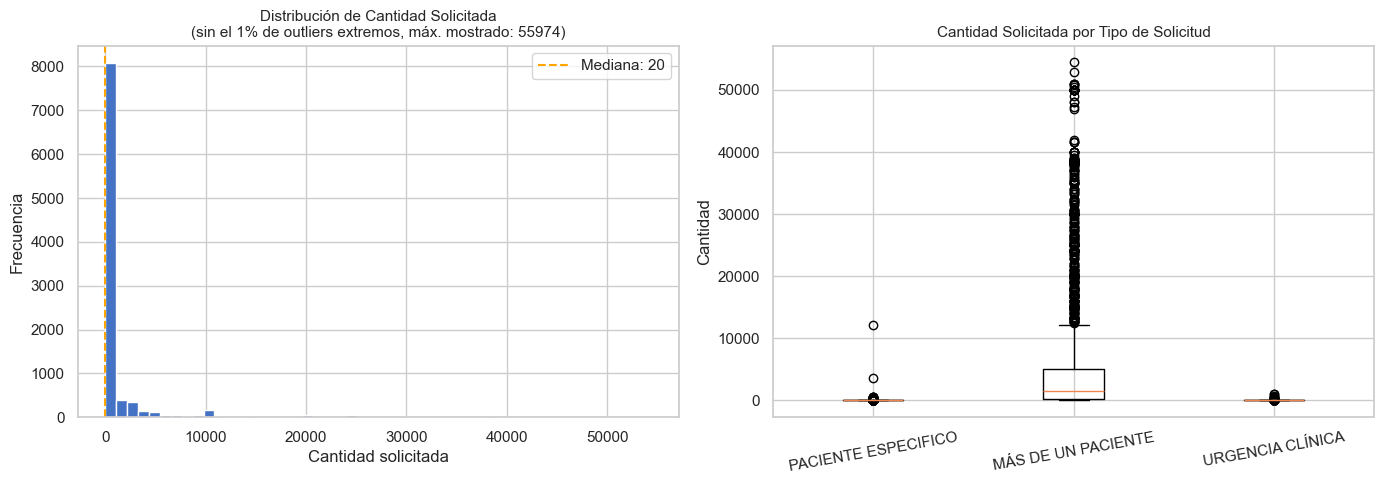

In [58]:
# ─── Histograma + boxplot de CANTIDAD_SOLICITADA ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (filtrar outliers extremos para ver mejor la distribución)
p99 = cantidad.quantile(0.99)
cantidad_filtrada = cantidad[cantidad <= p99]
ax1.hist(cantidad_filtrada, bins=50, color='#4472C4', edgecolor='white')
ax1.set_title(f'Distribución de Cantidad Solicitada\n(sin el 1% de outliers extremos, máx. mostrado: {p99:.0f})', fontsize=11)
ax1.set_xlabel('Cantidad solicitada')
ax1.set_ylabel('Frecuencia')
ax1.axvline(cantidad.median(), color='orange', linestyle='--', label=f'Mediana: {cantidad.median():.0f}')
ax1.legend()

# Boxplot por tipo de solicitud
df['CANTIDAD_NUM'] = pd.to_numeric(df['CANTIDAD_SOLICITADA'], errors='coerce')
df_box = df[df['CANTIDAD_NUM'] <= p99]
ax2.boxplot([df_box[df_box['TIPO_DE_SOLICITUD']==t]['CANTIDAD_NUM'].dropna()
             for t in df['TIPO_DE_SOLICITUD'].unique()],
            labels=df['TIPO_DE_SOLICITUD'].unique())
ax2.set_title('Cantidad Solicitada por Tipo de Solicitud', fontsize=11)
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', labelrotation=10)

plt.tight_layout()
plt.savefig('grafico_cantidad_solicitada.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECCIÓN 8 — Vista de muestra del dataset

In [44]:
# ─── Primeras 5 filas ────────────────────────────────────────────────────────
print('PRIMERAS 5 FILAS:')
df.head(5)

PRIMERAS 5 FILAS:


,FECHA_DE_AUTORIZACIÓN,TIPO_DE_SOLICITUD,SOLICITANTE/IMPORTADOR,IUM,PRINCIPIO_ACTIVO1,CONCENTRACIÓN_DELMEDICAMENTO1,UNIDAD_MEDIDA1,PRINCIPIO_ACTIVO2,CONCENTRACIÓN_DEL_MEDICAMENTO2,UNIDAD_MEDIDA2,FORMA_FARMACÉUTICA,NOMBRE_COMERCIAL_,CANTIDAD_SOLICITADA,PRESENTACIÓN_COMERCIAL,DIAGNOSTICO_CIE-1NO REPORTA,CÓDIGO_DIAGNOSTICO_CIE-10
0,2026-06-12 05:00:00,PACIENTE ESPECIFICO,VALENTECH PHARMA COLOMBIA SAS,2E1063651000102,ELEXACAFTOR / TEZACAFTOR / IVACAFTOR,100/50/150,mg,NO APLICA,NO APLICA,NO APLICA,TABLETA,TRIKAFTA,6.0,CAJAS X 28 DOSIS\n\nCADA CAJA CONTIENE KIT POR...,"FIBROSIS QUISTICA, SIN OTRA ESPECIFICACION",E849
1,2026-03-19 05:00:00,MÁS DE UN PACIENTE,HB HUMAN BIOSCIENCE S.A.S.,1C1001051002100,ASPARAGINASA ERWINIA,10000,UI,NO APLICA,NO APLICA,NO APLICA,POLVO LIOFILIZADO PARA RECONSTITUIR A SOLUCIÓN...,HB DADANTII,300.0,CAJAS X UN (1) VIAL,LEUCEMIA LINFOBLASTICA AGUDA,C910
2,2026-03-19 05:00:00,URGENCIA CLÍNICA,GESTIFARMA S.A.S.,1T1062941000101,TEPOTINIB,225,mg,NO APLICA,NO APLICA,NO APLICA,TABLETA,TEPMETKO,3.0,CAJAS X 60 TABLETAS,"TUMOR MALIGNO DE LOS BRONQUIOS O DEL PULMON, P...",C349
3,2026-03-19 05:00:00,PACIENTE ESPECIFICO,GLOBAL SERVICE PHARMACEUTICAL S.A.S.,1A1014981000100,AZTREONAM,75,mg,NO APLICA,NO APLICA,NO APLICA,POLVO PARA NEBULIZAR,CAYSTON,2.0,CAJAS X 84 VIALES + DISOLVENTE,FIBROSIS QUISTICA CON MANIFESTACIONES PULMONARES,E840
4,2026-03-19 05:00:00,PACIENTE ESPECIFICO,GLOBAL SERVICE PHARMACEUTICAL S.A.S.,1P1063601000100,CLORURO DE POTASIO,10,mEq,NO APLICA,NO APLICA,NO APLICA,TABLETA,NO REPORTADO,6.0,FRASCOS X 100 TABLETAS,OTROS TRASTORNOS RESULTANTES DE LA FUNCION TUB...,N258


In [46]:
# ─── Muestra aleatoria de 5 filas de urgencia clínica ────────────────────────
print('MUESTRA DE URGENCIAS CLÍNICAS:')
df[df['TIPO_DE_SOLICITUD'] == 'URGENCIA CLÍNICA'].sample(5, random_state=42)

MUESTRA DE URGENCIAS CLÍNICAS:


,FECHA_DE_AUTORIZACIÓN,TIPO_DE_SOLICITUD,SOLICITANTE/IMPORTADOR,IUM,PRINCIPIO_ACTIVO1,CONCENTRACIÓN_DELMEDICAMENTO1,UNIDAD_MEDIDA1,PRINCIPIO_ACTIVO2,CONCENTRACIÓN_DEL_MEDICAMENTO2,UNIDAD_MEDIDA2,FORMA_FARMACÉUTICA,NOMBRE_COMERCIAL_,CANTIDAD_SOLICITADA,PRESENTACIÓN_COMERCIAL,DIAGNOSTICO_CIE-1NO REPORTA,CÓDIGO_DIAGNOSTICO_CIE-10
3594,2024-02-13 05:00:00,URGENCIA CLÍNICA,VALENTECH PHARMA COLOMBIA SAS,2E1040751000100,ELEXACAFTOR / TEZACAFTOR / IVACAFTOR,"50/25/37,5",mg,IVACAFTOR,75,mg,TABLETA,TRIKAFTA,3.0,CAJAS X 84 TABLETAS,FIBROSIS QUISTICA CON MANIFESTACIONES INTESTIN...,E841
9532,2018-06-20 05:00:00,URGENCIA CLÍNICA,VALENTECH PHARMA COLOMBIA SAS,1A1007581000100,AGANIRSEN,0.86,mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCION,GS-101,3.0,CAJA X 7 TIRAS X 10 UNIDOSIS C/U,NEOVASCULARIZACION DE LA CORNEA,H164
6177,2022-04-01 05:00:00,URGENCIA CLÍNICA,GLOBAL MARKET ALLIANCE S.A.S.,1T1001911000100,TOLVAPTAN,15,mg,NO APLICA,NO APLICA,NO APLICA,TABLETA,SAMSCA,36.0,CAJA X 10 TABLETAS,"RIÑON POLIQUISTICO, TIPO ADULTO",Q612
6566,2021-11-24 05:00:00,URGENCIA CLÍNICA,GRUPO MEDIKA S.A.S.,1T1001911000100,TOLVAPTAN,15,mg,NO APLICA,NO APLICA,NO APLICA,TABLETA,SAMSCA,54.0,CAJA X 10 TABLETAS,"RIÑON POLIQUISTICO, TIPO ADULTO",Q612
8561,2019-06-05 05:00:00,URGENCIA CLÍNICA,VESALIUS PHARMA S.A.S.,1C1000151002100,CIDOFOVIR,75,mg/mL,NO APLICA,NO APLICA,NO APLICA,SOLUCIÓN INYECTABLE,TILLOMED LAB,4.0,CAJA X 1 VIAL,ANEMIA APLASTICA DEBIDA A OTROS AGENTES EXTERNOS,D612


---
## SECCIÓN 9 — Resumen ejecutivo de la exploracion inicial inicial

Este resumen es el **insumo directo para diseñar el ETL** en la siguiente fase.

In [43]:
print('=' * 65)
print('  DIAGNÓSTICO INICIAL — DATASET MVND INVIMA 2018–2026')
print('=' * 65)

print(f"""
      ESTRUCTURA
  • {df.shape[0]:,} registros | {df.shape[1]} columnas
  • Período: {df['FECHA_DE_AUTORIZACIÓN'].min().date()} → {df['FECHA_DE_AUTORIZACIÓN'].max().date()}
  • Hoja del archivo: 'Data'

  CALIDAD DE DATOS (valores faltantes críticos)
  • PRINCIPIO_ACTIVO2    : ~91.7% vacío → columna casi inútil, evaluar eliminar
  • CONCENTRACIÓN 2       : ~91.7% vacío → igual
  • UNIDAD_MEDIDA2       : ~91.7% vacío → igual
  • DIAGNOSTICO_CIE-10   : 13.4% sin diagnóstico → impacta el análisis diagnóstico
  • CÓDIGO_CIE-10        : 17.0% vacío → requiere imputación o exclusión
  • NOMBRE_COMERCIAL     :  9.5% vacío → coincide con urgencias clínicas

""")
print('=' * 65)
print('DIAGNÓSTICO COMPLETO — Listo para diseñar el ETL')
print('=' * 65)

  DIAGNÓSTICO INICIAL — DATASET MVND INVIMA 2018–2026

      ESTRUCTURA
  • 10,017 registros | 16 columnas
  • Período: 2018-01-09 → 2026-06-12
  • Hoja del archivo: 'Data'

  CALIDAD DE DATOS (valores faltantes críticos)
  • PRINCIPIO_ACTIVO2    : ~91.7% vacío → columna casi inútil, evaluar eliminar
  • CONCENTRACIÓN 2       : ~91.7% vacío → igual
  • UNIDAD_MEDIDA2       : ~91.7% vacío → igual
  • DIAGNOSTICO_CIE-10   : 13.4% sin diagnóstico → impacta el análisis diagnóstico
  • CÓDIGO_CIE-10        : 17.0% vacío → requiere imputación o exclusión
  • NOMBRE_COMERCIAL     :  9.5% vacío → coincide con urgencias clínicas


DIAGNÓSTICO COMPLETO — Listo para diseñar el ETL


---
##  ¿Qué sigue después de este notebook?

Con este diagnóstico en mano, el **siguiente notebook limpieza de datos**:

| Notebook | Contenido |
|---|---|
| `01_Exploracion_Inicial_MVND.ipynb` |  Este notebook — Reconocimiento del dato |
| `02_Limpieza_Dataset_MVND.ipynb` | Limpieza, normalización, tratamiento de nulos |
| `03_EDA_Medicamentos.ipynb` | Iteración 1 — Análisis de medicamentos |
| `04_EDA_Diagnosticos.ipynb` | Iteración 2 — Análisis de diagnósticos CIE-10 |
| `05_EDA_Importadores.ipynb` | Iteración 3 — Análisis de importadores |
| `06_EDA_Temporal.ipynb` | Iteración 4 — Análisis temporal |
| `07_Analisis_Estadistico.ipynb` | Chi-cuadrado, V de Cramér, asociaciones |
| `08_Ingesta_Modelo_mysql.ipynb` | Cuaderno para la ingesta automatizada de  |
---
*Proyecto MVND INVIMA — Diplomado en Ingeniería y Ciencia de Datos — Unicomfacauca 2026*